# 01 · Cellular Automata — Recovering the Rule from the Pattern

In notebook 00 we recovered a network from its behaviour table. Here we do
something that looks like magic but is the same idea: we watch a **cellular
automaton** paint a picture in space and time, and from the picture alone we
recover the exact local rule that produced it.

A cellular automaton (CA) *is* a Boolean network in disguise:

* each **cell** is a node;
* each cell listens to its **neighbours** (that is the wiring);
* every cell uses the **same rule** (that is the shared gate).

So our deconvolution should work on it. Let us see the patterns first.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


## 1. The patterns

An *elementary* CA has each cell look at itself and its two neighbours, and a
number 0–255 (the "rule") says what to do for each of the 8 neighbourhoods. Three
famous ones:

* **Rule 90** — a fractal (the Sierpiński triangle);
* **Rule 30** — looks random, used as a randomness source;
* **Rule 110** — capable of universal computation.

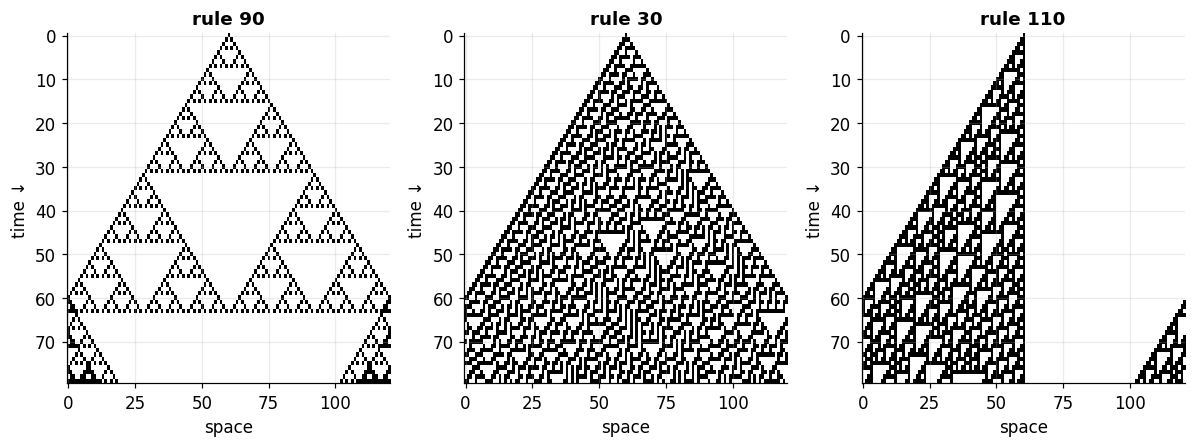

Same simple machine, three different worlds: a fractal, chaos, and a computer.


In [2]:
from ca_deconvolution import evolve_eca

W, STEPS = 121, 80
single_seed = [1 if i == W // 2 else 0 for i in range(W)]   # one cell ON in the middle

fig, axes = plt.subplots(1, 3, figsize=(11, 4.2))
for ax, rule in zip(axes, [90, 30, 110]):
    diagram = evolve_eca(rule, single_seed, STEPS)
    ax.imshow(diagram, cmap="binary", aspect="auto", interpolation="nearest")
    ax.set_title(f"rule {rule}"); ax.set_xlabel("space"); ax.set_ylabel("time ↓")
plt.tight_layout(); plt.show()
print("Same simple machine, three different worlds: a fractal, chaos, and a computer.")

## 2. Recover the rule from the picture

We now *hide the rule*. We only keep the space-time diagrams (a handful of runs
from random starts, so that all local neighbourhoods appear), and ask the
deconvolution to tell us the wiring and the gate of each cell.

In [3]:
from ca_deconvolution import deconvolve_ca, verify_ca, ca_global_map
from causalbool import evolve_network
import random

RULE = 30
w = 14                                     # small width so we can also test the WHOLE map
rng = random.Random(0)
diagrams = [evolve_eca(RULE, [rng.randint(0, 1) for _ in range(w)], 40) for _ in range(16)]

net, reports = deconvolve_ca(diagrams, max_radius=3)     # recover network from pictures alone
r0 = reports[0]
print(f"recovered (cell 0): neighbours (support) = {r0.support},  gate = {r0.canonical.gate}")
print("every cell has the SAME rule (a CA is homogeneous):",
      len({r.canonical.gate for r in reports}) == 1)

recovered (cell 0): neighbours (support) = [0, 1, 13],  gate = REGULATORY_DNF
every cell has the SAME rule (a CA is homogeneous): True


### Prove the equivalence — two ways

**Weak test:** the recovered network repaints every observed run exactly.
**Strong test:** its behaviour matches the automaton on *all* $2^{w}$ possible
states — the entire global map, not just the runs we happened to see.

In [4]:
check = verify_ca(diagrams, net, rule=RULE)
print("repaints every observed run exactly :", check["trajectory_exact"])
print("matches the WHOLE global map exactly:", check.get("global_map_exact"))

repaints every observed run exactly : True
matches the WHOLE global map exactly: True


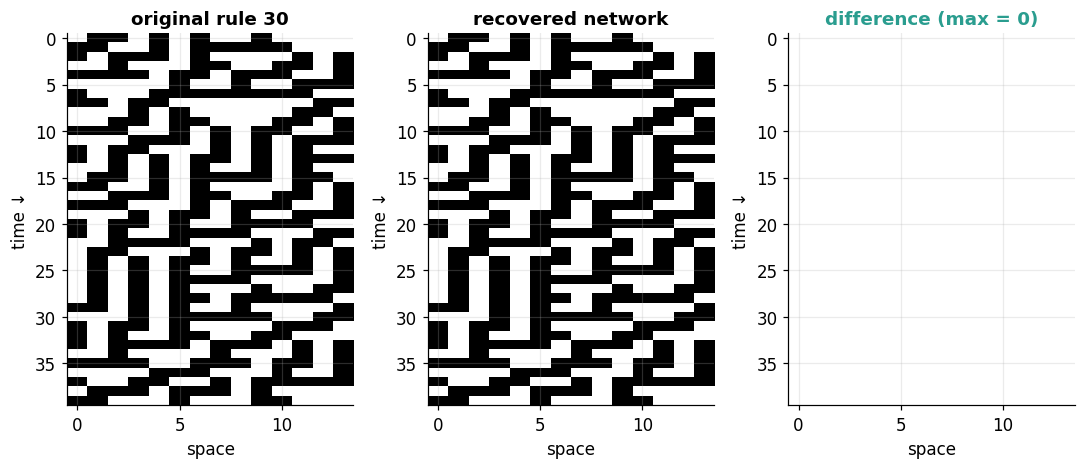

Identical, pixel for pixel: we recovered the rule from the picture alone.


In [5]:
# The visual proof of equivalence on a fresh initial condition
ic = [rng.randint(0, 1) for _ in range(w)]
orig = np.array(evolve_eca(RULE, ic, 40))
recon = np.array(evolve_network(net, ic, 40))
diff = np.abs(orig - recon)

fig, axes = plt.subplots(1, 3, figsize=(10, 4.4))
for ax, M, t in zip(axes, [orig, recon, diff],
                    ["original rule 30", "recovered network", "difference"]):
    ax.imshow(M, cmap="binary", aspect="auto", interpolation="nearest"); ax.set_title(t)
    ax.set_xlabel("space"); ax.set_ylabel("time ↓")
axes[2].set_title(f"difference (max = {diff.max()})", color=OK)
plt.tight_layout(); plt.show()
print("Identical, pixel for pixel: we recovered the rule from the picture alone.")

## 3. What gate *is* each rule?

The naming is honest: it discriminates between genuinely different rules.

In [6]:
from ca_deconvolution import deconvolve_ca as dca

def name_rule(rule, w=14, k=16):
    rng = random.Random(1)
    ds = [evolve_eca(rule, [rng.randint(0,1) for _ in range(w)], 40) for _ in range(k)]
    net, reps = dca(ds, max_radius=3)
    r = reps[0]
    return r.canonical.gate, r.support

for rule in [254, 90, 150, 30, 110]:
    gate, support = name_rule(rule)
    print(f"rule {rule:3d}:  gate {gate:14s}  uses cells {support}")
print("\n254 = OR, 90 = XOR of the two OUTER cells (centre dropped!), 150 = XOR of all three.")
print("30 and 110 match no single named gate, so they fall to a minimal clause form (REGULATORY_DNF).")

rule 254:  gate OR              uses cells [1, 13]
rule  90:  gate XOR             uses cells [1, 13]
rule 150:  gate XOR             uses cells [0, 1, 13]
rule  30:  gate REGULATORY_DNF  uses cells [0, 1, 13]
rule 110:  gate REGULATORY_DNF  uses cells [0, 1, 13]

254 = OR, 90 = XOR of the two OUTER cells (centre dropped!), 150 = XOR of all three.
30 and 110 match no single named gate, so they fall to a minimal clause form (REGULATORY_DNF).


## 4. It cannot cheat: complexity is tracked, not manufactured

A method that "fits anything" would give a short rule even for random data. Ours
does the opposite: the *size* of the recovered rule grows with the true complexity
of the function. AND needs one clause; rule 30 needs three; a random function of
the same size needs many. This is the guardrail that makes every later claim
trustworthy.

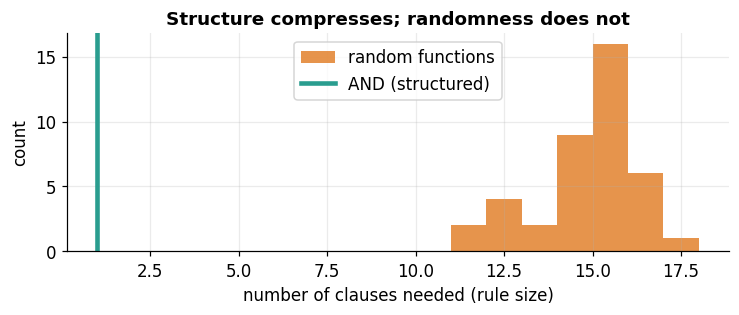

AND needs 1 clause; random 6-input functions need ~14 on average.


In [7]:
from deconvolution import minimal_dnf

def clause_count(col):
    return len(minimal_dnf(col))

# truth tables over 6 inputs: AND vs random
rng = random.Random(7)
and6 = [1 if x == (2**6 - 1) else 0 for x in range(2**6)]
randoms = [[rng.randint(0, 1) for _ in range(2**6)] for _ in range(40)]

sizes = [clause_count(r) for r in randoms]
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(sizes, bins=range(min(sizes), max(sizes)+2), color=BAD, alpha=0.8, label="random functions")
ax.axvline(clause_count(and6), color=OK, lw=3, label="AND (structured)")
ax.set_xlabel("number of clauses needed (rule size)"); ax.set_ylabel("count"); ax.legend()
ax.set_title("Structure compresses; randomness does not")
plt.tight_layout(); plt.show()
print(f"AND needs {clause_count(and6)} clause; random 6-input functions need ~{int(np.mean(sizes))} on average.")

## Takeaways

* A cellular automaton is a Boolean network; our deconvolution recovers its local
  rule from the space-time picture **exactly** — verified against the entire global
  map, not just the runs we saw.
* The gate naming is meaningful (OR, XOR, XOR-of-outer-cells, …) and complex rules
  fall to a minimal clause form.
* The method never manufactures simplicity: rule size tracks true complexity, so it
  cannot "explain" randomness.

**Next (02):** real biological gene networks, and the special **regulatory** gate
(activators and inhibitors) that they need.